# Introduction to Rainfields

Rainfields 3 is a comprehensive framework providing real-time quality control for operational weather radar networks.  The system currently serves the entire Australian Weather Radar Network comprising of over 75 weather radars. This offers a large array of weather radar derived products in near real time.

https://thredds.nci.org.au/thredds/catalog/rq0/rainfields3/catalog.html

## More details about Rainfields



The native coordinate system for weather radar data is three dimensional in elevation, azimuth, slant range relative to the radar location.  Many applications require radar data as a two dimensional grid which is referenced geographically.

Previous examples are focused on using volumetric data, now we start using the data derived on cartesian grid.

First product derived from Rainfields is the ground reflectivity.

Rainfields estimates surface reflectivity using Ordinary Kriging, excluding clutter and correcting bright band effects via VPR. Unlike traditional CAPPI, it avoids seams, overshooting shallow rain, and melting-layer contamination. By leveraging DEM-based ground altitude, it delivers accurate reflectivity in complex terrain, improving precipitation analysis and radar-based rainfall estimation.

Here will look into how we can convert those ground reflectivity derived from radar to raw rainfall rate.


# Reading Ground Reflectivity data

In [ ]:
## Importing basic python packages
import os
import xarray as xr
import requests
import zipfile
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
# To be able to run in Google Colab it is needed to install cartopy library
# cartopy is a python library to allow display/plot geographical datasets
# link to the Colab version of this notebook is:
# https://colab.research.google.com/github/vlouf/Monash-Radar-Workshop-2025/blob/main/03-Rainfields/Introduction%20to%20rainfields.ipynb
#
# if not using Google colab, the next line is not needed
!pip install cartopy

In [ ]:
import cartopy.crs as ccrs

In [ ]:
### Helper function to download and extract zip file from AURA Thredds server

def download_file(url, local_filename):
    print(f"Downloading {url}...")
    response = requests.get(url, stream=True)
    response.raise_for_status()
    with open(local_filename, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
    print(f"Successfully downloaded {local_filename}")
    return local_filename

def extract_zip(zip_file, extract_dir):
    print(f"Extracting {zip_file} to {extract_dir}...")
    os.makedirs(extract_dir, exist_ok=True)
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Extraction completed")
    return extract_dir

In [ ]:
# location of the gndrefl products for Melbourne radar (id 2) valid for 2019/12/01
zip_file_url = "https://thredds.nci.org.au/thredds/fileServer/rq0/rainfields3/2/2019/gndrefl/2_20191201.gndrefl.zip"
local_zip_filename = "2_20191201.gndrefl.zip"
extracted_dir = "./extracted_data"

In [ ]:
# download the ZIP file and extract in local server
download_file(zip_file_url,local_zip_filename)
extract_zip(local_zip_filename,extracted_dir)

Successfully downloaded 2_20191201.gndrefl.zip
Extracting 2_20191201.gndrefl.zip to ./extracted_data...
Extraction completed


'./extracted_data'

In [ ]:
! ls -lh ./extracted_data/*2_2019*.gndrefl*.nc | tail -n 10

-rw-r--r-- 1 root root 577K Nov 21 05:19 ./extracted_data/2_20191201_230042.gndrefl.nc
-rw-r--r-- 1 root root 575K Nov 21 05:19 ./extracted_data/2_20191201_230642.gndrefl.nc
-rw-r--r-- 1 root root 573K Nov 21 05:19 ./extracted_data/2_20191201_231245.gndrefl.nc
-rw-r--r-- 1 root root 575K Nov 21 05:19 ./extracted_data/2_20191201_231842.gndrefl.nc
-rw-r--r-- 1 root root 574K Nov 21 05:19 ./extracted_data/2_20191201_232442.gndrefl.nc
-rw-r--r-- 1 root root 571K Nov 21 05:19 ./extracted_data/2_20191201_233045.gndrefl.nc
-rw-r--r-- 1 root root 568K Nov 21 05:19 ./extracted_data/2_20191201_233642.gndrefl.nc
-rw-r--r-- 1 root root 561K Nov 21 05:19 ./extracted_data/2_20191201_234245.gndrefl.nc
-rw-r--r-- 1 root root 555K Nov 21 05:19 ./extracted_data/2_20191201_234842.gndrefl.nc
-rw-r--r-- 1 root root 550K Nov 21 05:19 ./extracted_data/2_20191201_235445.gndrefl.nc


In [ ]:
## Read one of the ground reflectivity file using xarray
da = xr.open_dataset('./extracted_data/2_20191201_054842.gndrefl.nc')

In [ ]:
# display contents of dataset
da

<xarray.Dataset> Size: 6MB
Dimensions:           (y: 512, n2: 2, x: 512)
Coordinates:
  * y                 (y) float64 4kB 127.8 127.2 126.8 ... -126.8 -127.2 -127.8
  * x                 (x) float64 4kB -127.8 -127.2 -126.8 ... 126.8 127.2 127.8
Dimensions without coordinates: n2
Data variables:
    valid_time        datetime64[ns] 8B ...
    proj              int8 1B ...
    y_bounds          (y, n2) float64 8kB ...
    x_bounds          (x, n2) float64 8kB ...
    reflectivity      (y, x) float64 2MB ...
    error             (y, x) float64 2MB ...
    doppler_velocity  (y, x) float64 2MB ...
Attributes:
    Conventions:   CF-1.7
    title:         Corrected Reflectivity at Ground
    institution:   Commonwealth of Australia, Bureau of Meteorology (ABN 92 6...
    licence:       http://www.bom.gov.au/other/copyright.shtml
    source:        rainfields 3.1.7 drs-rainfields 2019-04-29
    station_id:    2
    station_name:  Melb

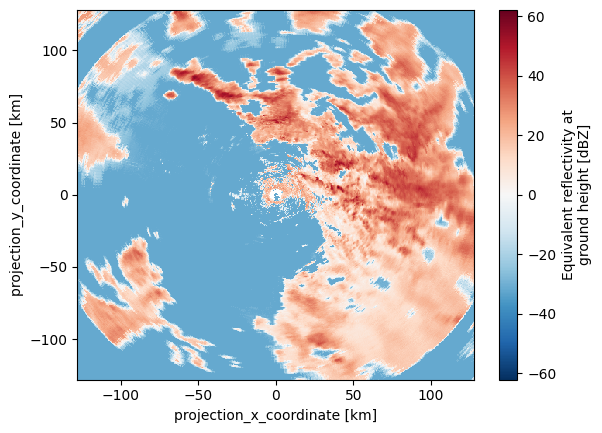

In [ ]:
# Plot reflectivity in projection coordinates (but without a geographical reference)

da.reflectivity.plot()

## Converting Reflectivity into raw rain rate

The relationship between rainfall and reflectivity is expressed as a power-law equation,

Z=aR^b, where (Z) is the radar reflectivity, (R) is the rainfall rate, and '\(a\)' and '\(b\)' are constants that vary depending on the type of precipitation. These parameters depends mainly on the microphysical processes driving rainfall, including dropsize distribution and terminal velocity of raindrops.

For Melbourne radar,  <br>
a = 303.2 <br>
b = 1.66

In [ ]:
MAX_DBZ = 53.0  ## This is to limit the higher reflectivity mainly values due hail
a_param = 303.2
b_param = 1.66

def reflectivity_to_rainrate(dbz, a, b):
    """Cap dBZ and convert to rain rate R."""
    dbz_capped = xr.where(dbz >= MAX_DBZ, MAX_DBZ, dbz, keep_attrs=True)
    Z = 10 ** (dbz_capped / 10.0)
    R = (Z / a) ** (1.0 / b)
    return R


In [ ]:
# transform reflectivity into rain_rates
rain_rate = reflectivity_to_rainrate(da.reflectivity,a=a_param,b=b_param)

# provide some attributes to the new DataArray
rain_rate.name = 'rain_rate'
rain_rate.attrs.update({
    'long_name': 'Rainfall rate',
    'units': 'mm/hr',
    'grid_mapping' :'proj',
    'conversion': f'Z-R with a={a_param}, b={b_param}, capped at {MAX_DBZ} dBZ'
})

# assign original coordinates with attributes to the new dataarray
rain_rate = rain_rate.assign_coords(x=da.x,y=da.y)

In [ ]:
# add a new rain-rate dataarray to the original dataset
da = da.assign(rain_rate = rain_rate)
da

<xarray.Dataset> Size: 8MB
Dimensions:           (y: 512, n2: 2, x: 512)
Coordinates:
  * y                 (y) float64 4kB 127.8 127.2 126.8 ... -126.8 -127.2 -127.8
  * x                 (x) float64 4kB -127.8 -127.2 -126.8 ... 126.8 127.2 127.8
Dimensions without coordinates: n2
Data variables:
    valid_time        datetime64[ns] 8B ...
    proj              int8 1B ...
    y_bounds          (y, n2) float64 8kB ...
    x_bounds          (x, n2) float64 8kB ...
    reflectivity      (y, x) float64 2MB 17.12 16.75 18.19 ... -12.92 -14.26
    error             (y, x) float64 2MB ...
    doppler_velocity  (y, x) float64 2MB ...
    rain_rate         (y, x) float64 2MB 0.3438 0.3266 ... 0.005329 0.004425
Attributes:
    Conventions:   CF-1.7
    title:         Corrected Reflectivity at Ground
    institution:   Commonwealth of Australia, Bureau of Meteorology (ABN 92 6...
    licence:       http://www.bom.gov.au/other/copyright.shtml
    source:        rainfields 3.1.7 drs-rainfields 2019-04-29
    station_id:    2
    station_name:  Melb

In [ ]:
### Additional function for plotting

class cmap_rf3(object):
    """Define color maps for RF3 rainfall products."""

    from matplotlib.colors import ListedColormap
    import matplotlib.pyplot as plt

    # RAINFALL
    rainfall_colors = np.array([(255, 255, 255),  # 0.0
                                (245, 245, 255),  # 0.2
                                (180, 180, 255),  # 0.5
                                (120, 120, 255),  # 1.5
                                (20,  20, 255),  # 2.5
                                (0, 216, 195),  # 4.0
                                (0, 150, 144),  # 6.0
                                (0, 102, 102),  # 10
                                (255, 255,   0),  # 15
                                (255, 200,   0),  # 20
                                (255, 150,   0),  # 30
                                (255, 100,   0),  # 40
                                (255,   0,   0),  # 50
                                (200,   0,   0),  # 60
                                (120,   0,   0),  # 75
                                (40,   0,   0)])  # > 100
    rainfall_colors = rainfall_colors/255.
    cm_rainfall = ListedColormap(rainfall_colors, 'rainfall')
    rainfall_levels = [0., 1.0, 2.0, 4, 6, 10, 15, 20,
                       30, 40, 50, 60, 80, 100, 150, 200, 300]
    rainfall_levels_hr = [0., 0.2, 0.5, 1.5, 2.5, 4, 5, 7, 10, 15,
                          20, 25, 30, 35, 40, 45, 50]
    rainfall_levels_10min = [0., 0.1, 0.2, 0.3, 0.4, 0.5, 1.0, 2.0, 3.0, 4.0,
                          5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 15.0]

# Make a Cartopy Projection Object from netcdf Proj info
def get_ccrs_from_proj(ds):
    if 'proj' in ds.variables:
        try:
            return ccrs.AlbersEqualArea(central_longitude=ds.proj.attrs['longitude_of_central_meridian'],
                            central_latitude=ds.proj.attrs['latitude_of_projection_origin'],
                            false_easting=ds.proj.attrs['false_easting'],
                            false_northing=ds.proj.attrs['false_northing'],
                            standard_parallels=ds.proj.attrs['standard_parallel'],
                            globe=None)
        except Exception as err:
            print(err)
            return ccrs.PlateCarree()


def transform_coords_from_km_to_m(ds):
    """Transform coords from km to m (if required)."""
    if ds is not None:
        if 'x' in ds.coords:
            if 'units' in ds.x.attrs:
                if ds.x.units == 'km':
                    ds['x'] = ds.x*1000.
                    ds.x.attrs.update({'units':'m'})
                    ds.x.attrs.update({'standard_name':'projection_x_coordinate'})
                    message = '; Original coords x transformed to m from km'
                    if 'history' in ds.attrs:
                        ds.attrs['history'] += message
                    else:
                        ds.attrs['history'] = message
                if ds.y.units == 'km':
                    ds['y'] = ds.y*1000.
                    ds.y.attrs.update({'units':'m'})
                    ds.y.attrs.update({'standard_name':'projection_y_coordinate'})
                    ds.attrs['history'] += '; Original coords y transformed to m from km'
    return ds

#### PROJECTION and COORDINATES


Rainfields employs the Albers Equal Area projection to preserve area accuracy across the 2D grids, ensuring reliable spatial analysis of precipitation patterns over large regions with small distortions, while keeping the area of the pixels constant.

In [ ]:
## get the projection info from dataset
target_proj = get_ccrs_from_proj(da)
print(target_proj)

+proj=aea +ellps=WGS84 +lon_0=144.752 +lat_0=-37.852 +x_0=0.0 +y_0=0.0 +lat_1=-36.3 +lat_2=-39.4 +no_defs +type=crs


In [ ]:
# display coordinates information
# note the units atrribute
print(da.x)

<xarray.DataArray 'x' (x: 512)> Size: 4kB
array([-127.75, -127.25, -126.75, ...,  126.75,  127.25,  127.75])
Coordinates:
  * x        (x) float64 4kB -127.8 -127.2 -126.8 -126.2 ... 126.8 127.2 127.8
Attributes:
    standard_name:  projection_x_coordinate
    units:          km
    bounds:         x_bounds


In [ ]:
# Transform coordinates from Km to Meters to allow geographic mapping
da_km = transform_coords_from_km_to_m(da)

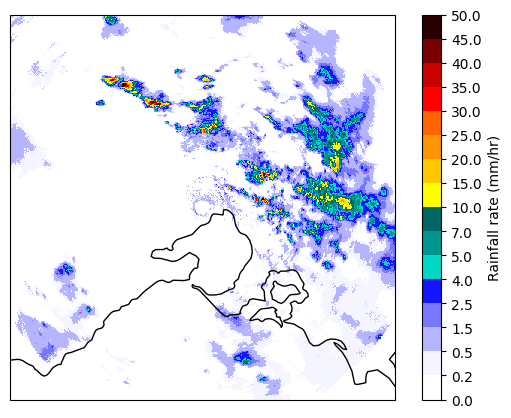

In [ ]:
# Mapping Rain Rates in correct geographic projection

plt.figure(figsize=(7,5))
ax = plt.axes(projection=target_proj)
ax.set_xmargin(0)
ax.set_ymargin(0)
to_plot = da_km.rain_rate
to_plot.plot(ax=ax,
             vmin=0,
             cmap=cmap_rf3.cm_rainfall,
             levels=cmap_rf3.rainfall_levels_hr,
             cbar_kwargs={'ticks': cmap_rf3.rainfall_levels_hr,
                          'label': 'Rainfall rate (mm/hr)',
                          'extend': 'neither',
                          })
ax.coastlines('10m')

In [ ]:
### Exercise
### Use the historical reflectivity data from Melbourne radar (2) to download datasets, convert refectivity into rainfall rates and plot for a rainfall event in 2021-06-09T06:00:00UTC


# Exercise
Use the historical reflectivity data from Melbourne radar (2) to download datasets, convert refectivity into rainfall rates and plot for a rainfall event in 2021-06-09T06:00:00UTC

Remember to download the daily zip file, and extract single radar files, first.

A solution is presented later but try to complate the exercise by yourself.

Steps:
1) download the daily ZIP file
2) Extract the ZIP files contents
3) Read the single reflectivity file that correspnd with the time and date to plot.
4) Correct and transform coordinates (if a geographic map is needed)
5) Plot reflectivity
6) Transform reflectivty into rain rates using Z-R relationship
7) Plot rain rates




##SOLUTION

In [ ]:
# ## Download compressed daily file and extract single files

# zip_file_url = "https://thredds.nci.org.au/thredds/fileServer/rq0/rainfields3/2/2021/gndrefl/2_20210609.gndrefl.zip"
# local_zip_filename = "2_20210609.gndrefl.zip"
# extracted_dir = "./extracted_data"

# download_file(zip_file_url,local_zip_filename)
# extract_zip(local_zip_filename,extracted_dir)

In [ ]:
# ! ls -lh ./extracted_data/*2_2021*.gndrefl*.nc | tail -n 10

In [ ]:
# ## Read one of the ground reflectivity file using xarray
# da = xr.open_dataset('./extracted_data/2_20210609_060000.gndrefl.nc')

# #assign km units to coordinates and transform to meters to allow geographical mapping
# da.x.attrs['units'] ='km'
# da.y.attrs['units'] = 'km'
# da_km = transform_coords_from_km_to_m(da)

In [ ]:
# # PLOT REFLECTIVITY
# da.reflectivity.plot()

In [ ]:
# # transform reflectivity to rain rates

# rain_rate = reflectivity_to_rainrate(da.reflectivity,a=a_param,b=b_param)

# rain_rate.name = 'rain_rate'
# rain_rate.attrs.update({
#     'long_name': 'Rainfall rate',
#     'units': 'mm/hr',
#     'conversion': f'Z-R with a={a_param}, b={b_param}, capped at {MAX_DBZ} dBZ'
# })

# # assign original coordinates with attributes to the new dataarray
# rain_rate = rain_rate.assign_coords(x=da.x,y=da.y)

# # add a new rain-rate dataarray to the original dataset
# da = da.assign(rain_rate = rain_rate)

In [ ]:
# # plot rain rates using proper projection

# plt.figure(figsize=(7,5))
# ax = plt.axes(projection=target_proj)
# ax.set_xmargin(0)
# ax.set_ymargin(0)
# to_plot = da_km.rain_rate
# to_plot.plot(ax=ax,
#              vmin=0,
#              cmap=cmap_rf3.cm_rainfall,
#              levels=cmap_rf3.rainfall_levels_hr,
#              cbar_kwargs={'ticks': cmap_rf3.rainfall_levels_hr,
#                           'label': 'Rainfall rate (mm/hr)',
#                           'extend': 'neither',
#                           })
# ax.coastlines('10m')

In [ ]:
##END